# 2. Correlation and Outlier Analysis — Sensor Relationship and Anomaly Detection

This notebook performs correlation-driven exploration and outlier analysis on the vessel’s sensor network.  
It serves as the core analytical stage that links raw signal relationships to potential sensor faults or abnormal events.  
The outputs generated here — correlation matrices, CHI (Correlation Health Index), and outlier visualizations —  
feed directly into the system’s reliability and health scoring layer.

---

### Objectives

- Quantify **pairwise sensor relationships** using multiple correlation metrics (Pearson, Spearman, Kendall).  
- Identify **time-lagged dependencies** and **rolling correlation drifts** to uncover dynamic coupling.  
- Cluster sensors based on correlation patterns to reveal functional groupings.  
- Compute **CHI (Correlation Health Index)** to rank sensors by overall network consistency.  
- Detect and visualize **statistical and ML-based outliers**, classifying them as potential faults or anomalies.  
- Generate correlation and outlier results to be reused in later phases (statistical diagnostics, feature scoring, ML).

---

### Why This Matters

Vessel sensors often operate as part of an interconnected system —  
temperature, pressure, and flow readings can influence each other dynamically.  
When one sensor deviates sharply from its correlated peers, it can signal a **fault**, **drift**, or **calibration issue**.  

By quantifying these relationships, this notebook establishes a **correlation health baseline** for the vessel’s sensor ecosystem,  
making it easier to detect abnormal signals and prioritize maintenance actions.

---

### Notebook Structure

| Section | Description |
|:--------|:-------------|
| **1. Correlation Analysis** | Measures inter-sensor dependencies using linear and nonlinear methods. |
| **2. Dynamic Correlation (Lag & Rolling)** | Evaluates time-shifted and evolving relationships between sensors. |
| **3. Sensor Clustering** | Groups sensors with similar correlation patterns using hierarchical clustering. |
| **4. CHI Computation** | Derives the Correlation Health Index for each sensor. |
| **5. Outlier Analysis** | Detects abnormal readings using both statistical and ML-based approaches. |
| **6. Visualization** | Produces heatmaps, rolling plots, and outlier overlays for result interpretation. |


## Installs, and Module Imports

For Installation, start a virtual env, activate it then install requirements.txt

Then import the modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import grangercausalitytests
from itertools import combinations
import os
import warnings
from datetime import datetime
import glob
import json
from datetime import datetime, timedelta
import io
import datashader as ds
import datashader.transfer_functions as tf
from datashader.mpl_ext import dsshow
import colorcet
import hvplot.pandas
import holoviews as hv
from holoviews.operation.datashader import datashade, dynspread
hv.extension('bokeh')
import missingno as msno
import random
import networkx as nx
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

## Correlation Analysis

In [ ]:
merged_df = pd.read_csv("/Users/yasmine/Kongsberg/merged_for_correlation.csv")


In [ ]:
merged_df.head()

,Timestamp,LNGMEGIA.CT007.01_Meas1_PRIM,LNGMEGIA.CT026_Meas1_PRIM,LNGMEGIA.CT021.01_Meas1_PRIM,LNGMEGIA.CT056.01_Meas1_PRIM,LNGMEGIA.CT030.12_Meas1_PRIM,LNGMEGIA.CT012.01_Meas1_PRIM,LNGMEGIA.CT015.01_Meas1_PRIM,LNGMEGIA.CT032.13_Meas1_PRIM,LNGMEGIA.CT028_Meas1_PRIM,...,LNGMEGIA.CT055.01_Meas1_PRIM,LNGMEGIA.CT022.01_Meas1_PRIM,LNGMEGIA.CT004.01_Meas1_PRIM,LNGMEGIA.CT009.01_Meas1_PRIM,LNGMEGIA.CT014.01_Meas1_PRIM,LNGMEGIA.CT033.13_Meas1_PRIM,LNGMEGIA.CT031.12_Meas1_PRIM,LNGMEGIA.CT013.01_Meas1_PRIM,LNGMEGIA.CT020.01_Meas1_PRIM,LNGMEGIA.CT006.01_Meas1_PRIM
0,2024-08-14 06:48:00+00:00,0.489782,0.425616,0.445647,0.0,0.001595,0.290990,0.25180,0.027058,0.429418,...,0.260666,0.401866,0.43920,0.290131,0.244152,0.0,0.002506,0.515766,0.334853,0.373569
1,2024-08-14 06:49:00+00:00,0.489878,0.424654,0.445742,0.0,0.001595,0.291097,0.25172,0.027058,0.428568,...,0.260666,0.402072,0.43932,0.290228,0.244143,0.0,0.002358,0.515873,0.334949,0.373711
2,2024-08-14 06:50:00+00:00,0.490021,0.424566,0.445885,0.0,0.001595,0.291257,0.25164,0.027092,0.429113,...,0.260666,0.402227,0.43948,0.290326,0.244134,0.0,0.002432,0.516034,0.335046,0.373853
3,2024-08-14 06:51:00+00:00,0.490116,0.423341,0.445980,0.0,0.001595,0.291364,0.25160,0.027058,0.429332,...,0.260666,0.402330,0.43960,0.290423,0.244126,0.0,0.002616,0.516195,0.335190,0.373995
4,2024-08-14 06:52:00+00:00,0.490164,0.423474,0.446123,0.0,0.001595,0.291471,0.25156,0.027067,0.429506,...,0.260666,0.402434,0.43972,0.290520,0.244117,0.0,0.002395,0.516302,0.335384,0.374136


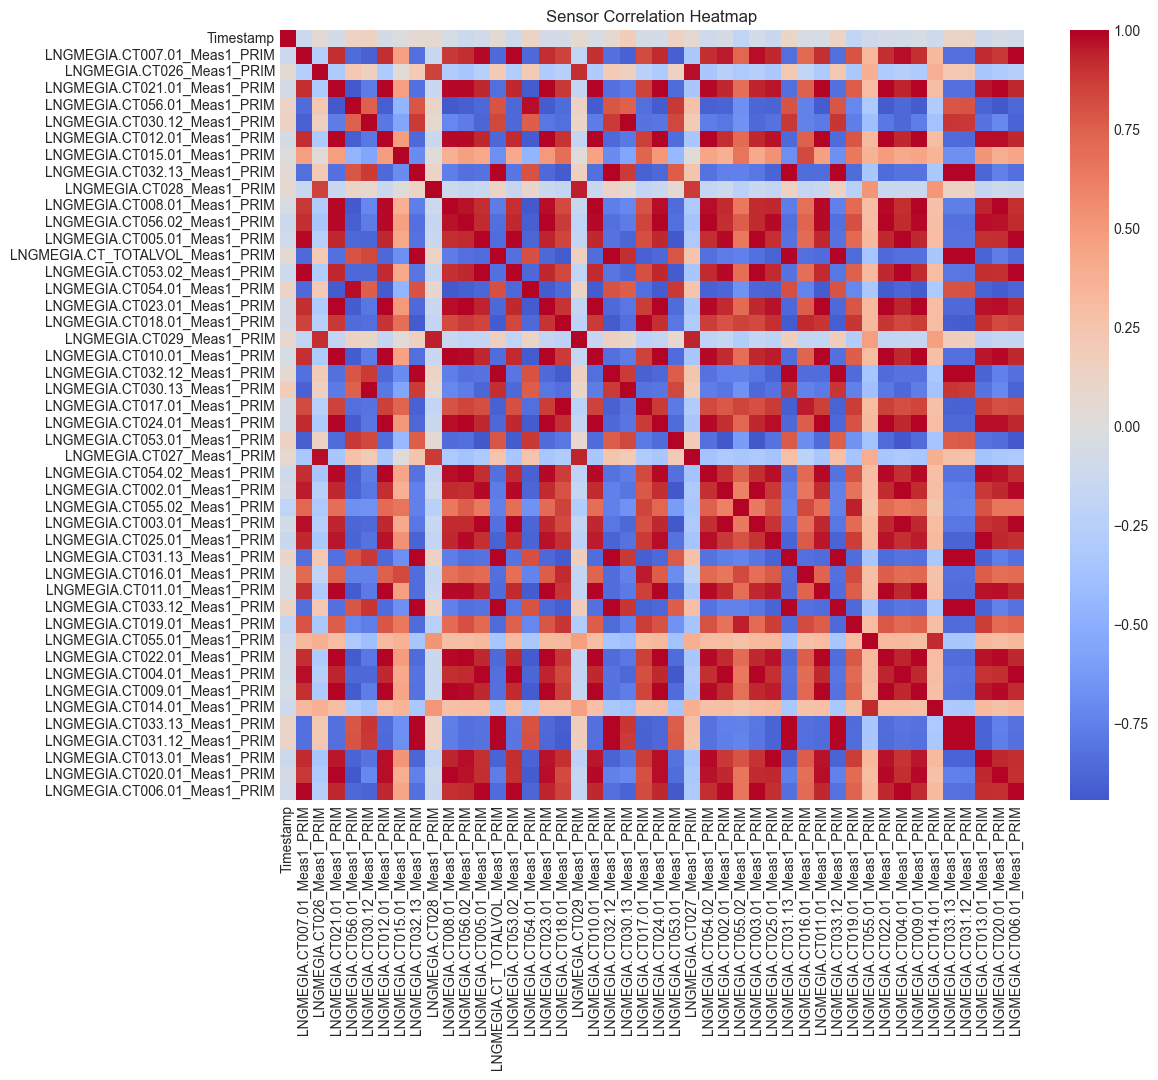

In [ ]:
corr = merged_df.corr(method="pearson")
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Sensor Correlation Heatmap")
plt.show()


In [ ]:
corr_pearson = merged_df.corr(method='pearson')

In [ ]:
print("Pearson Correlation:\n", corr_pearson)

Pearson Correlation:
                                  Timestamp  LNGMEGIA.CT007.01_Meas1_PRIM  \
Timestamp                         1.000000                     -0.126189   
LNGMEGIA.CT007.01_Meas1_PRIM     -0.126189                      1.000000   
LNGMEGIA.CT026_Meas1_PRIM         0.046563                     -0.273919   
LNGMEGIA.CT021.01_Meas1_PRIM     -0.065949                      0.909257   
LNGMEGIA.CT056.01_Meas1_PRIM      0.127860                     -0.851344   
LNGMEGIA.CT030.12_Meas1_PRIM      0.139417                     -0.904736   
LNGMEGIA.CT012.01_Meas1_PRIM     -0.055852                      0.910472   
LNGMEGIA.CT015.01_Meas1_PRIM      0.002661                      0.462624   
LNGMEGIA.CT032.13_Meas1_PRIM      0.056173                     -0.830818   
LNGMEGIA.CT028_Meas1_PRIM         0.060342                     -0.152274   
LNGMEGIA.CT008.01_Meas1_PRIM     -0.052397                      0.881406   
LNGMEGIA.CT056.02_Meas1_PRIM     -0.121092                      0.

In [ ]:
corr_spearman = merged_df.corr(method='spearman')

In [ ]:
print("\nSpearman Correlation:\n", corr_spearman)


Spearman Correlation:
                                  Timestamp  LNGMEGIA.CT007.01_Meas1_PRIM  \
Timestamp                         1.000000                     -0.033179   
LNGMEGIA.CT007.01_Meas1_PRIM     -0.033179                      1.000000   
LNGMEGIA.CT026_Meas1_PRIM         0.038193                     -0.414178   
LNGMEGIA.CT021.01_Meas1_PRIM      0.066359                      0.838351   
LNGMEGIA.CT056.01_Meas1_PRIM      0.009454                     -0.452512   
LNGMEGIA.CT030.12_Meas1_PRIM      0.062863                     -0.865146   
LNGMEGIA.CT012.01_Meas1_PRIM      0.046853                      0.843817   
LNGMEGIA.CT015.01_Meas1_PRIM      0.039467                      0.628876   
LNGMEGIA.CT032.13_Meas1_PRIM     -0.012841                     -0.687421   
LNGMEGIA.CT028_Meas1_PRIM         0.085450                     -0.257295   
LNGMEGIA.CT008.01_Meas1_PRIM      0.064962                      0.819320   
LNGMEGIA.CT056.02_Meas1_PRIM     -0.135566                      

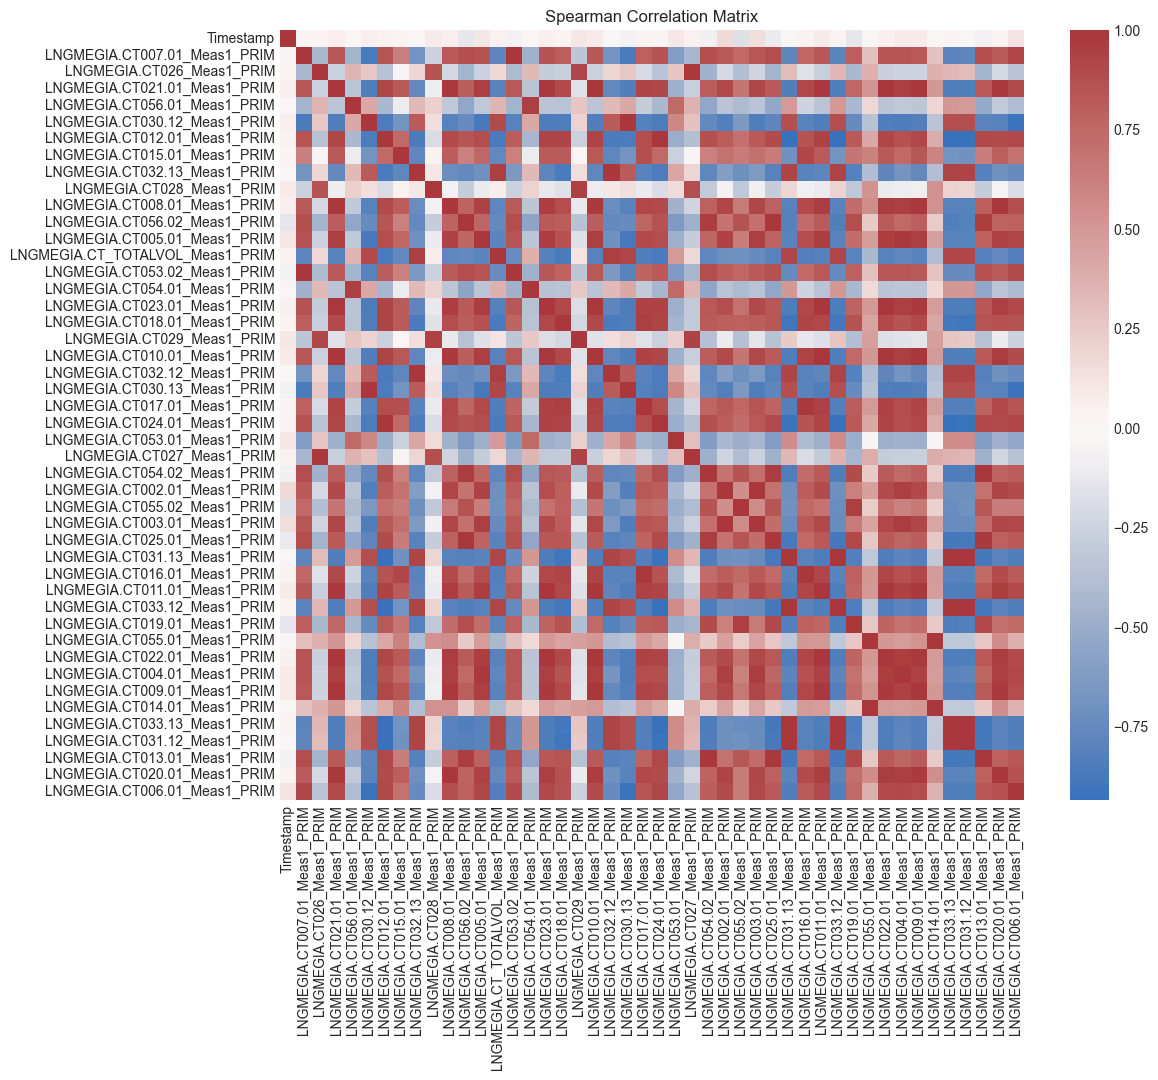

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_spearman, cmap="vlag", center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

In [ ]:
corr_kendall = merged_df.corr(method='kendall')

In [ ]:
print("\nKendall Correlation:\n", corr_kendall)


Kendall Correlation:
                                  Timestamp  LNGMEGIA.CT007.01_Meas1_PRIM  \
Timestamp                         1.000000                      0.022825   
LNGMEGIA.CT007.01_Meas1_PRIM      0.022825                      1.000000   
LNGMEGIA.CT026_Meas1_PRIM         0.014107                     -0.295136   
LNGMEGIA.CT021.01_Meas1_PRIM      0.079575                      0.660344   
LNGMEGIA.CT056.01_Meas1_PRIM      0.026075                     -0.271499   
LNGMEGIA.CT030.12_Meas1_PRIM      0.009238                     -0.679682   
LNGMEGIA.CT012.01_Meas1_PRIM      0.046441                      0.678298   
LNGMEGIA.CT015.01_Meas1_PRIM      0.056817                      0.413574   
LNGMEGIA.CT032.13_Meas1_PRIM     -0.094484                     -0.460463   
LNGMEGIA.CT028_Meas1_PRIM         0.046878                     -0.205944   
LNGMEGIA.CT008.01_Meas1_PRIM      0.073448                      0.637645   
LNGMEGIA.CT056.02_Meas1_PRIM     -0.065642                      0

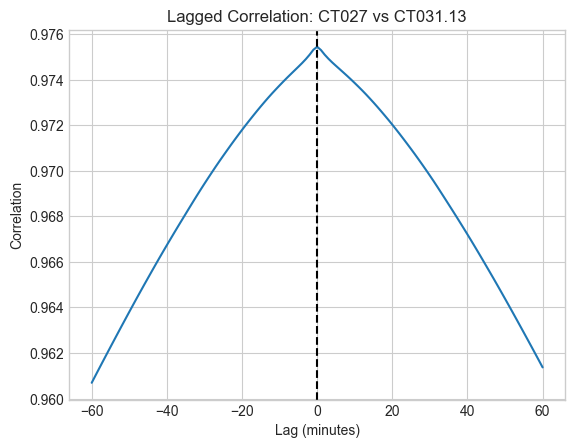

In [ ]:
# Time-Lagged Correlation (Dynamic Sensor Influence)
def lagged_corr(a, b, max_lag=60):
    """Compute correlation of a and b over time lags in minutes."""
    lags = range(-max_lag, max_lag+1)
    corrs = []
    for lag in lags:
        shifted_b = b.shift(lag)
        corr = a.corr(shifted_b)
        corrs.append(corr)
    return pd.Series(corrs, index=lags)

# Example between two sensors
sensor_a = merged_df['LNGMEGIA.CT027_Meas1_PRIM']
sensor_b = merged_df['LNGMEGIA.CT026_Meas1_PRIM']
corr_series = lagged_corr(sensor_a, sensor_b)

corr_series.plot(title="Lagged Correlation: CT027 vs CT031.13", xlabel="Lag (minutes)", ylabel="Correlation")
plt.axvline(0, color='black', linestyle='--')
plt.show()

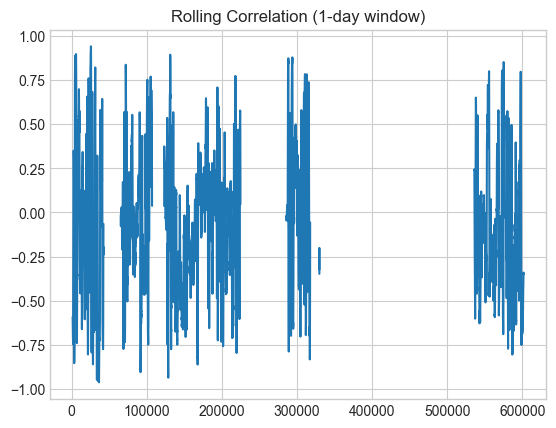

In [ ]:
# Rolling Window Correlation
window = 1440  # 1-day window if 1-minute sampling
rolling_corr = merged_df['LNGMEGIA.CT027_Meas1_PRIM'].rolling(window).corr(
    merged_df['LNGMEGIA.CT031.13_Meas1_PRIM']
)
rolling_corr.plot(title="Rolling Correlation (1-day window)")
plt.show()


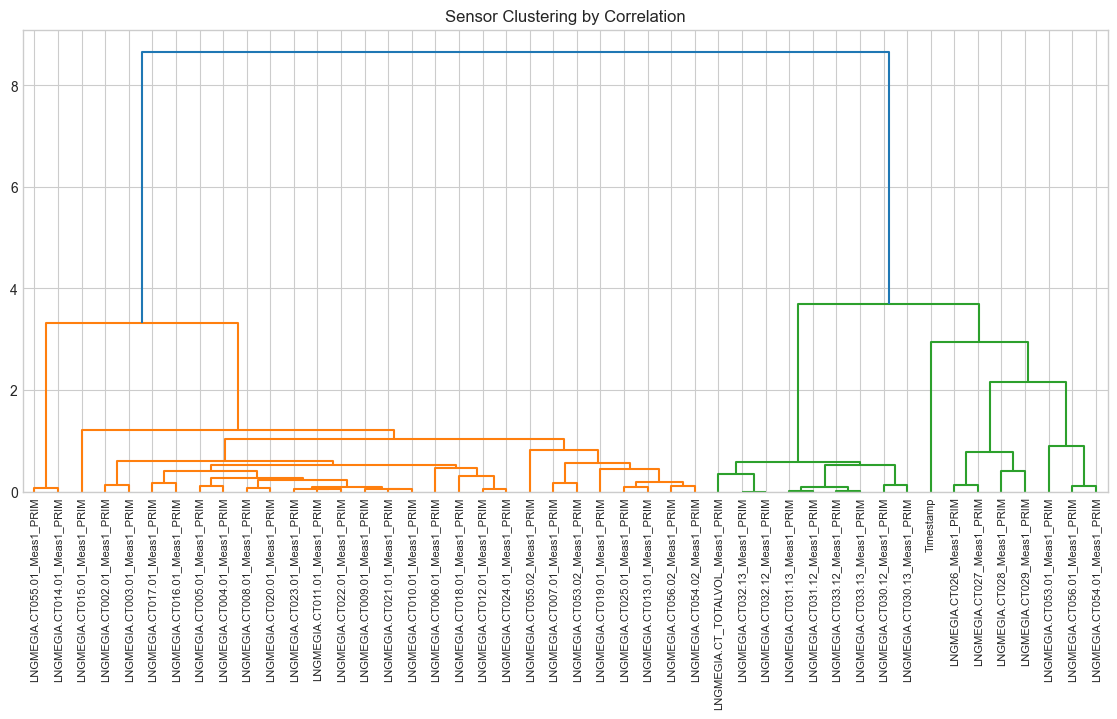

In [ ]:
# Cluster Sensors by Correlation
corr_matrix = merged_df.corr(method='spearman')
link = linkage(1 - corr_matrix, method='average')

plt.figure(figsize=(14, 6))
dendrogram(link, labels=corr_matrix.columns, leaf_rotation=90)
plt.title("Sensor Clustering by Correlation")
plt.show()


In [ ]:
# Mutual Information (Nonlinear Dependencies)
numeric_df = merged_df.select_dtypes(include=[np.number]).dropna(axis=1, how="all")

numeric_df = numeric_df.fillna(0)
cols = numeric_df.columns
mi_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        if i != j:
            mi = mutual_info_regression(
                numeric_df[[i]], numeric_df[j], discrete_features=False
            )
            mi_matrix.loc[i, j] = mi[0]
        else:
            mi_matrix.loc[i, j] = np.nan

sns.heatmap(mi_matrix, cmap="YlGnBu")
plt.title("Mutual Information Between Sensors (Nonlinear Relationships)")
plt.show()

In [ ]:
# Correlation Anomaly Index (CAI)
baseline_corr = numeric_df.corr()
rolling_corrs = numeric_df.rolling(window=1440).corr().groupby(level=0).mean()
deviation = (rolling_corrs - baseline_corr).abs().mean(axis=1)
deviation.plot(title="Correlation Anomaly Index (CAI)")
plt.show()


: 

In [ ]:
# Granger Causality (Temporal Influence)
data = numeric_df.iloc[:, :2].dropna()
print("\nGranger Causality Test Results:")
grangercausalitytests(data, maxlag=5, verbose=True)


Granger Causality Test Results:

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.9067  , p=0.0481  , df_denom=601508, df_num=1
ssr based chi2 test:   chi2=3.9068  , p=0.0481  , df=1
likelihood ratio test: chi2=3.9067  , p=0.0481  , df=1
parameter F test:         F=3.9067  , p=0.0481  , df_denom=601508, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2680.1519, p=0.0000  , df_denom=601505, df_num=2
ssr based chi2 test:   chi2=5360.3483, p=0.0000  , df=2
likelihood ratio test: chi2=5336.6049, p=0.0000  , df=2
parameter F test:         F=2680.1519, p=0.0000  , df_denom=601505, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1816.5804, p=0.0000  , df_denom=601502, df_num=3
ssr based chi2 test:   chi2=5449.8045, p=0.0000  , df=3
likelihood ratio test: chi2=5425.2644, p=0.0000  , df=3
parameter F test:         F=1816.5804, p=0.0000  , df_denom=601502, df_num=3

Granger Causality
number of lags (

{1: ({'ssr_ftest': (3.9067309286399596, 0.048093517728837465, 601508.0, 1),
   'ssr_chi2test': (3.906750413323099, 0.04809250405501709, 1),
   'lrtest': (3.906736553646624, 0.04809290071386108, 1),
   'params_ftest': (3.9067297545831026, 0.048093551335300695, 601508.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (2680.151864366234, 0.0, 601505.0, 2),
   'ssr_chi2test': (5360.348286165314, 0.0, 2),
   'lrtest': (5336.604906113818, 0.0, 2),
   'params_ftest': (2680.1518648027295, 0.0, 601505.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (1816.5803568013494, 0.0, 601502.0, 3),
   'ssr_chi2test': (5449.804491951263, 0.0, 3),
   'lrtest': (5425.264389480464, 0.0, 3),
   'params_ftest': (1816.5803567037062, 0.0, 601502.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 1., 0.]])]),
 4: ({'ssr_ftest': (1450.1561427777822, 0.0, 601499.0, 4),
   'ssr_chi2test': (580

In [ ]:
# =====================================================
# CONFIGURATION
# =====================================================
CLEAN_DIR = "/Users/yasmine/Kongsberg/cleaned_csv/cleaned"
OUTLIER_DIR = "/Users/yasmine/Kongsberg/cleaned_csv/outliers"
OUTPUT_DIR = "/Users/yasmine/Kongsberg/analysis_phase2"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
# ROLLING (TIME-VARYING) CORRELATION DRIFT (ALL SENSORS)

def rolling_correlation_all(window=1440):
    clean_files = [f for f in os.listdir(CLEAN_DIR) if f.endswith("_cleaned.csv")]
    sensor_names = [f.replace("_cleaned.csv", "") for f in clean_files]

    print(f"Computing rolling correlation for {len(sensor_names)} sensors...")

    for sensor_a, sensor_b in combinations(sensor_names, 2):
        clean_a = os.path.join(CLEAN_DIR, f"{sensor_a}_cleaned.csv")
        clean_b = os.path.join(CLEAN_DIR, f"{sensor_b}_cleaned.csv")

        try:
            df_a = pd.read_csv(clean_a, parse_dates=["Timestamp"])
            df_b = pd.read_csv(clean_b, parse_dates=["Timestamp"])

            merged = pd.merge(df_a[["Timestamp", "Value"]],
                              df_b[["Timestamp", "Value"]],
                              on="Timestamp",
                              suffixes=(f"_{sensor_a}", f"_{sensor_b}"))

            merged.set_index("Timestamp", inplace=True)

            rolling_corr = merged[f"Value_{sensor_a}"].rolling(window).corr(
                merged[f"Value_{sensor_b}"]
            )

            plt.figure(figsize=(12, 5))
            rolling_corr.plot(title=f"Rolling Correlation — {sensor_a} vs {sensor_b}")
            plt.ylabel("Correlation")
            plt.xlabel("Timestamp")
            plt.tight_layout()

            plt.savefig(os.path.join(OUTPUT_DIR, f"rolling_corr_{sensor_a}_{sensor_b}.png"))
            plt.close()

            print(f"Saved rolling correlation: {sensor_a} vs {sensor_b}")

        except Exception as e:
            print(f"Error processing {sensor_a} and {sensor_b}: {e}")

    print("Rolling correlation analysis complete for all pairs.")

In [ ]:
rolling_correlation_all(window=1440)

Computing rolling correlation for 45 sensors...
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT026_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT021.01_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT056.01_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT030.12_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT012.01_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT015.01_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT032.13_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT028_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT008.01_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT056.02_Meas1_PRIM
Saved rolling correlation: LNGMEGIA.CT007.01_Meas1_PRIM vs LNGMEGIA.CT005.01_M

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1037d3490>>
Traceback (most recent call last):
  File "/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Saved rolling correlation: LNGMEGIA.CT021.01_Meas1_PRIM vs LNGMEGIA.CT018.01_Meas1_PRIM


In [ ]:
def compute_chi(show_top=15):
    files = [f for f in os.listdir(CLEAN_DIR) if f.endswith("_cleaned.csv")]
    data_frames = []

    for f in files:
        df = pd.read_csv(
            os.path.join(CLEAN_DIR, f),
            usecols=["Timestamp", "Value"],
            parse_dates=["Timestamp"]
        )
        df.rename(columns={"Value": f.replace("_cleaned.csv", "")}, inplace=True)
        data_frames.append(df)

    # Merge all sensors by timestamp
    merged = data_frames[0]
    for df in data_frames[1:]:
        merged = pd.merge(merged, df, on="Timestamp", how="outer")

    merged = merged.set_index("Timestamp").interpolate(limit_direction="both")

    # Compute correlation matrix
    corr_matrix = merged.corr()

    # Compute average correlation score per sensor (CHI)
    chi = corr_matrix.mean(axis=1).sort_values(ascending=False)

    # Plot CHI directly (no saving)
    plt.figure(figsize=(12, 5))
    chi.head(show_top).plot(
        kind="bar",
        title=f"Correlation Health Index (Top {show_top} Sensors)",
        color="steelblue"
    )
    plt.ylabel("Average Correlation with Other Sensors")
    plt.xlabel("Sensor")
    plt.tight_layout()
    plt.show()

    print("\n--- Correlation Health Index (CHI) Summary ---")
    print(chi.head(show_top))
    print("\nTotal sensors analyzed:", len(chi))

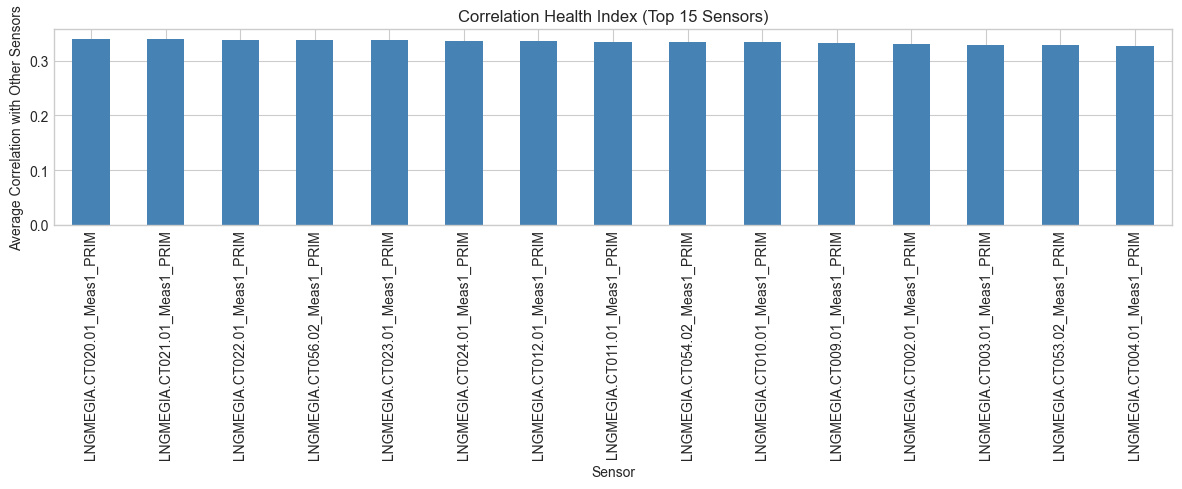


--- Correlation Health Index (CHI) Summary ---
LNGMEGIA.CT020.01_Meas1_PRIM    0.340213
LNGMEGIA.CT021.01_Meas1_PRIM    0.339043
LNGMEGIA.CT022.01_Meas1_PRIM    0.338181
LNGMEGIA.CT056.02_Meas1_PRIM    0.337952
LNGMEGIA.CT023.01_Meas1_PRIM    0.337196
LNGMEGIA.CT024.01_Meas1_PRIM    0.336046
LNGMEGIA.CT012.01_Meas1_PRIM    0.335430
LNGMEGIA.CT011.01_Meas1_PRIM    0.334703
LNGMEGIA.CT054.02_Meas1_PRIM    0.333933
LNGMEGIA.CT010.01_Meas1_PRIM    0.333822
LNGMEGIA.CT009.01_Meas1_PRIM    0.333254
LNGMEGIA.CT002.01_Meas1_PRIM    0.330267
LNGMEGIA.CT003.01_Meas1_PRIM    0.328737
LNGMEGIA.CT053.02_Meas1_PRIM    0.327979
LNGMEGIA.CT004.01_Meas1_PRIM    0.327795
dtype: float64

Total sensors analyzed: 45


In [ ]:
compute_chi(show_top=15)

In [ ]:
# SENSOR INFLUENCE GRAPH (Granger Summary for All Sensors)
def compute_granger_all(maxlag=5, p_threshold=0.05):
    clean_files = [f for f in os.listdir(CLEAN_DIR) if f.endswith("_cleaned.csv")]
    sensor_names = [f.replace("_cleaned.csv", "") for f in clean_files]

    pairs = []

    for sensor_a, sensor_b in combinations(sensor_names, 2):
        try:
            df_a = pd.read_csv(os.path.join(CLEAN_DIR, f"{sensor_a}_cleaned.csv"), parse_dates=["Timestamp"])
            df_b = pd.read_csv(os.path.join(CLEAN_DIR, f"{sensor_b}_cleaned.csv"), parse_dates=["Timestamp"])

            merged = pd.merge(df_a[["Timestamp", "Value"]], df_b[["Timestamp", "Value"]],
                              on="Timestamp", suffixes=(f"_{sensor_a}", f"_{sensor_b}")).dropna()

            # Ensure numeric
            merged = merged.select_dtypes(include=['float64', 'int64'])

            result = grangercausalitytests(merged, maxlag=maxlag, verbose=False)

            # Take min p-value across lags
            min_p = min([res[0]['ssr_chi2test'][1] for res in result.values()])

            if min_p < p_threshold:
                pairs.append((sensor_a, sensor_b, min_p))

        except Exception as e:
            print(f"Skipping {sensor_a} and {sensor_b}: {e}")

    print(f"Computed Granger causality for {len(pairs)} significant pairs.")
    return pairs


def sensor_influence_graph_all(threshold=0.05):
    pairs = compute_granger_all(p_threshold=threshold)

    if not pairs:
        print("No significant causality pairs found.")
        return

    G = nx.DiGraph()
    for src, tgt, p_value in pairs:
        G.add_edge(src, tgt, weight=1 - p_value)

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, k=0.5, iterations=50)
    nx.draw(G, pos, with_labels=True,
            node_color="lightblue", node_size=1800,
            font_size=9, edge_color="gray", arrowsize=15)
    plt.title("Sensor Influence Network (Granger Causality)")
    plt.tight_layout()
    plt.show()

In [ ]:
sensor_influence_graph_all()

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x110913390>>
Traceback (most recent call last):
  File "/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


## Outlier Analysis

In [ ]:
# =====================================================
# CONFIGURATION
# =====================================================
CLEAN_DIR = "/Users/yasmine/Kongsberg/cleaned_csv/cleaned"
OUTLIER_DIR = "/Users/yasmine/Kongsberg/cleaned_csv/outliers"
OUTPUT_DIR = "/Users/yasmine/Kongsberg/analysis_phase2"
os.makedirs(OUTPUT_DIR, exist_ok=True)


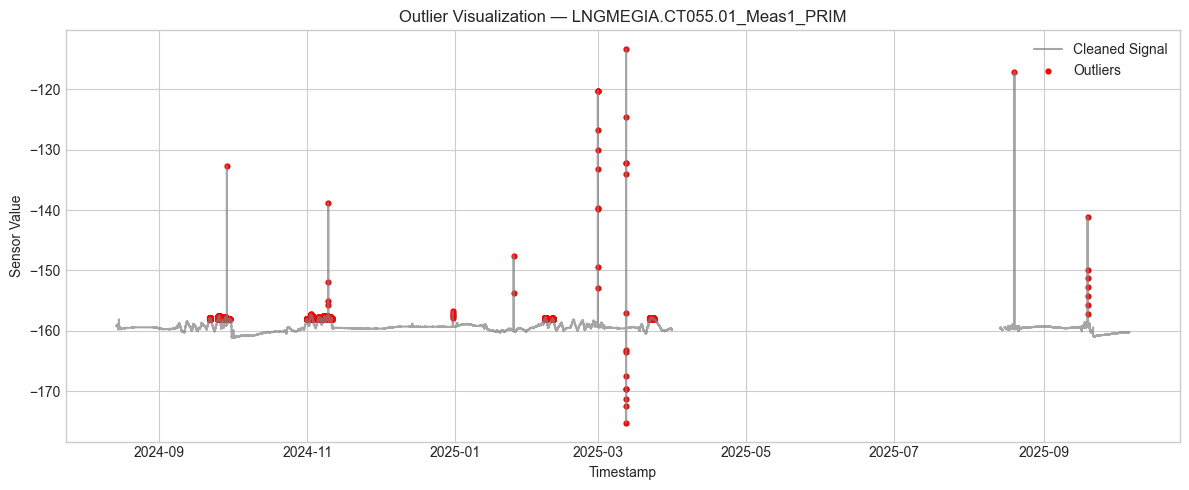

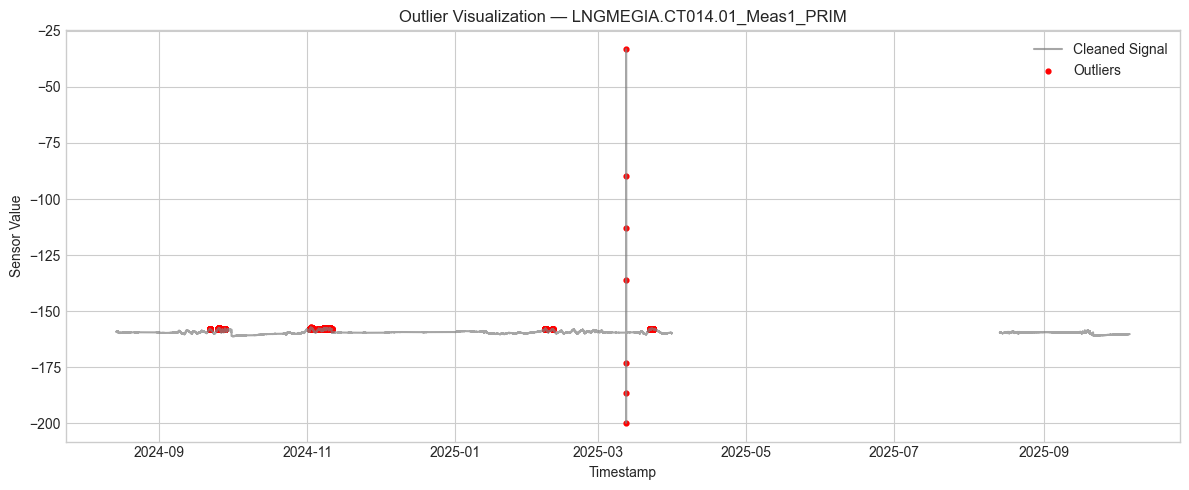

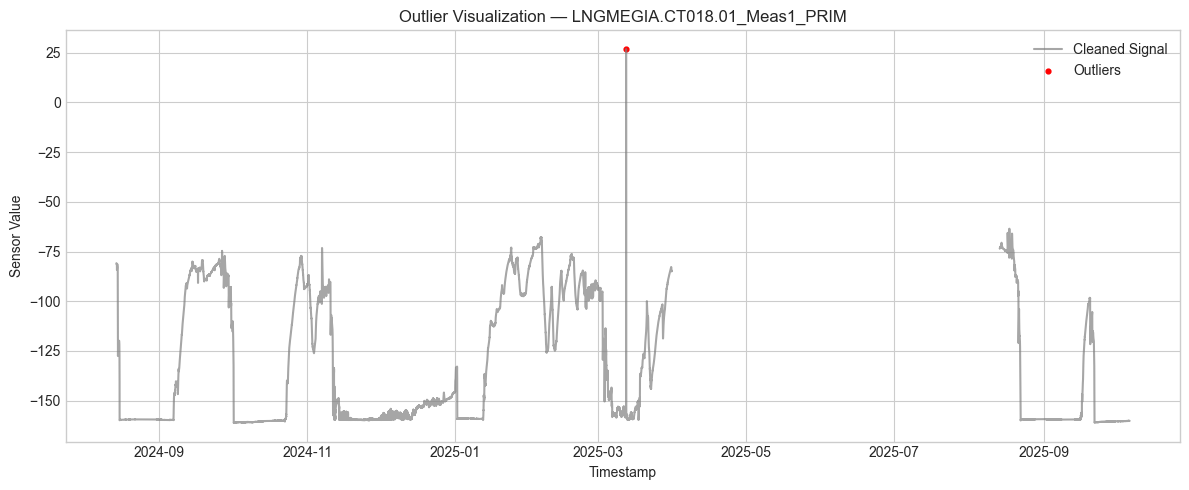

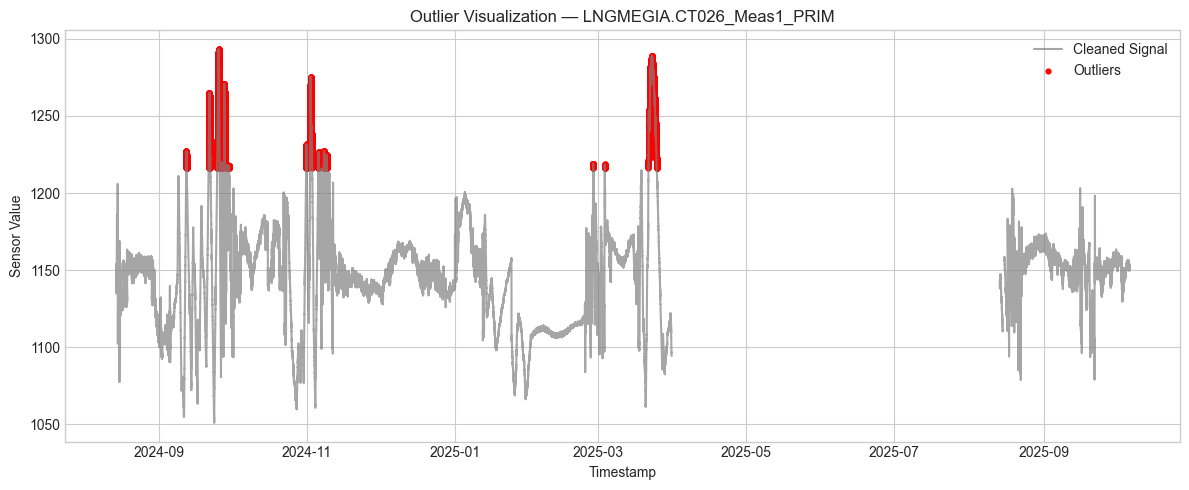

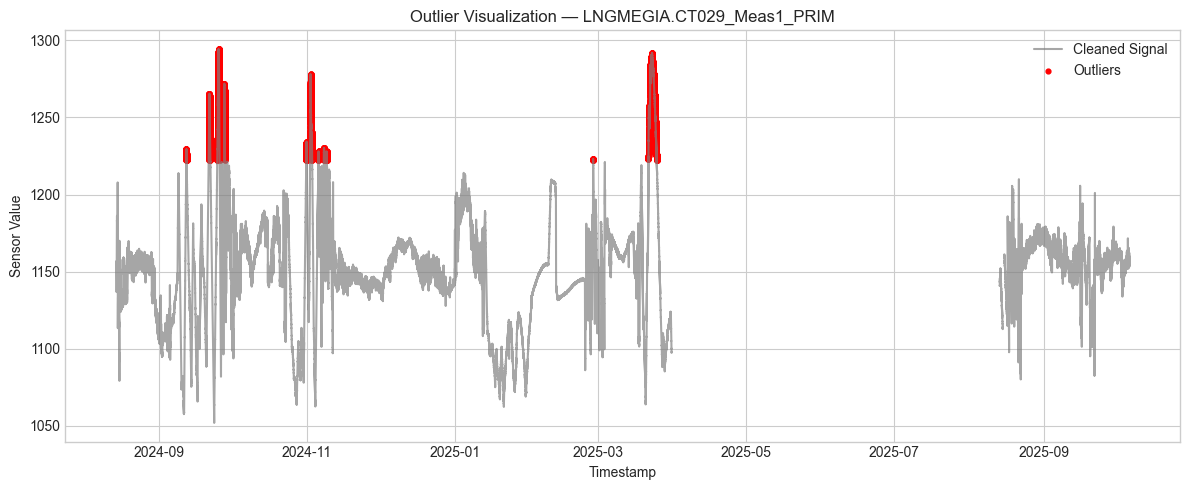

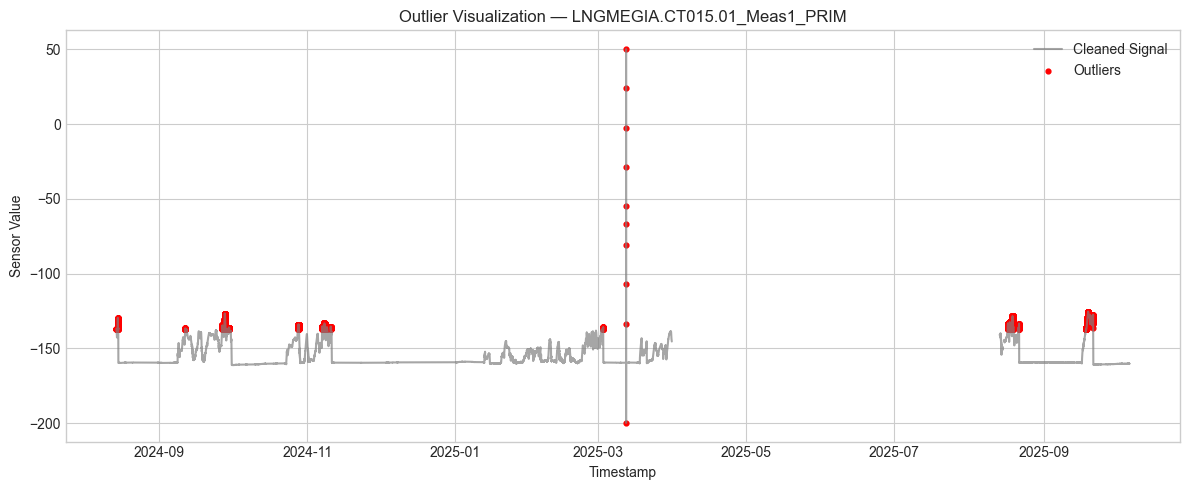

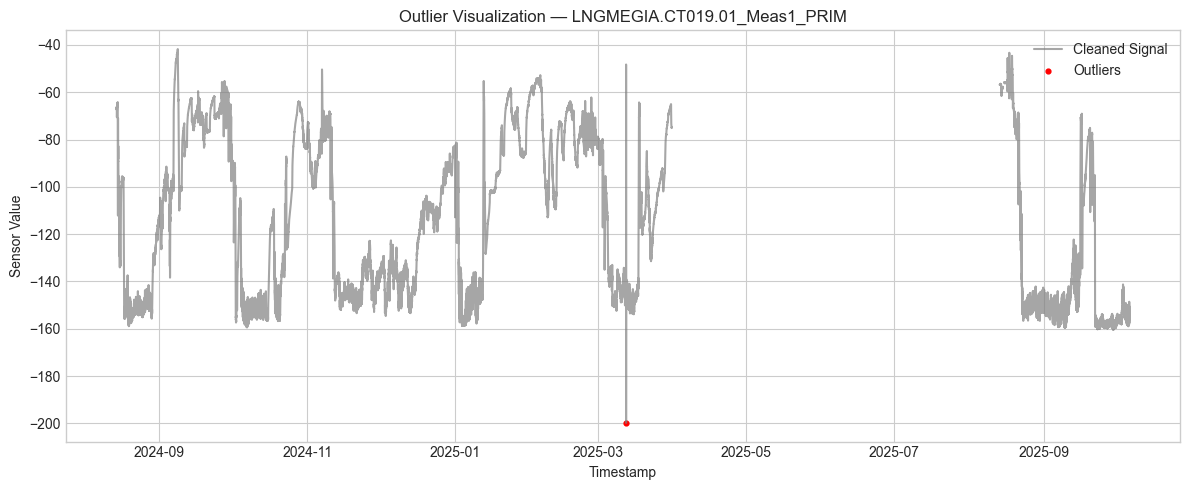

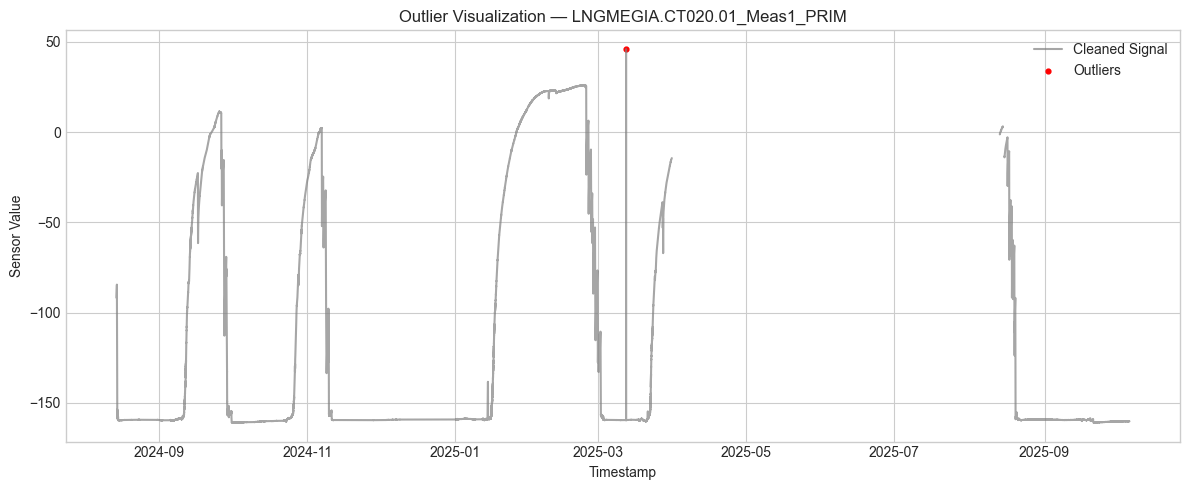

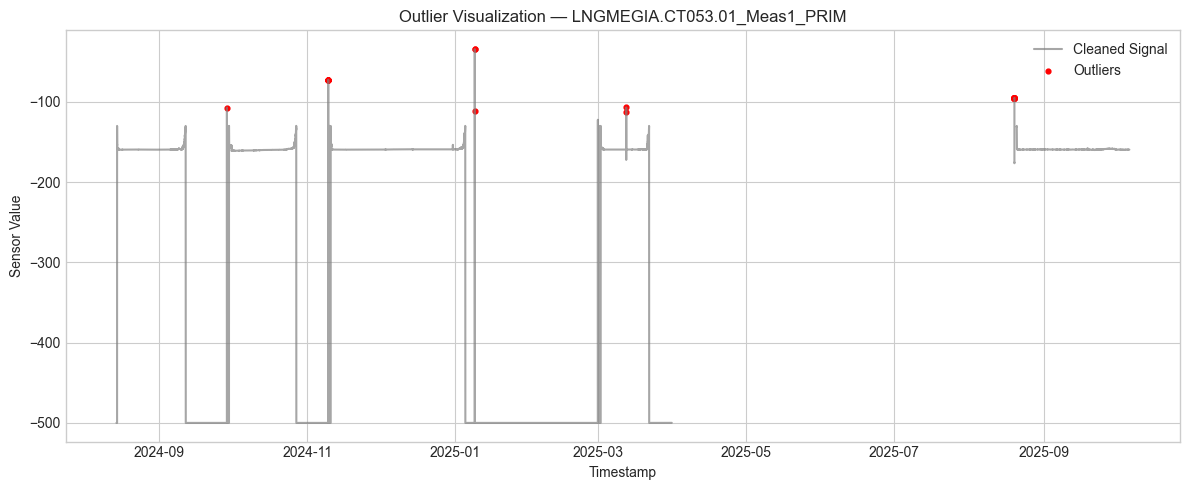

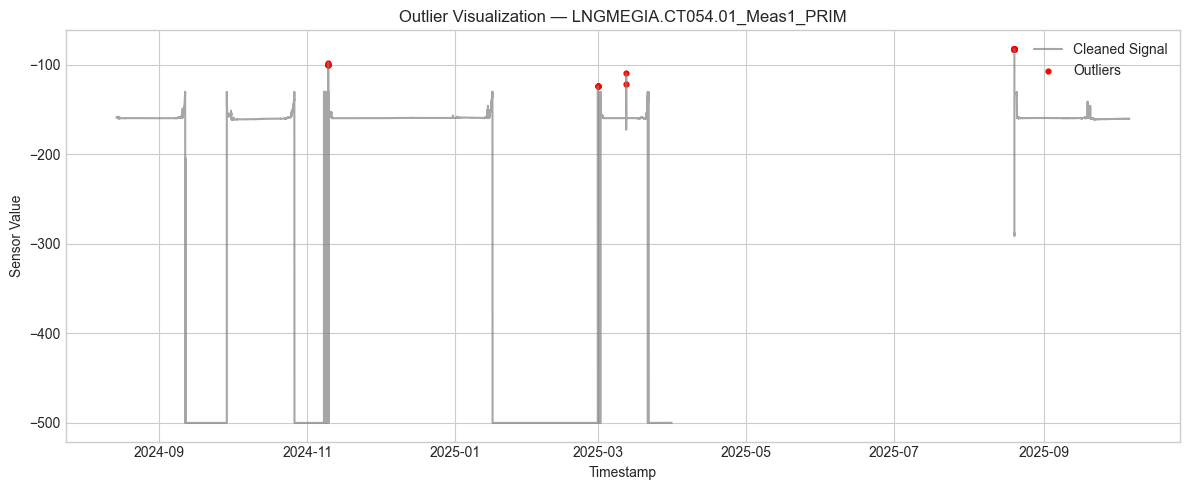

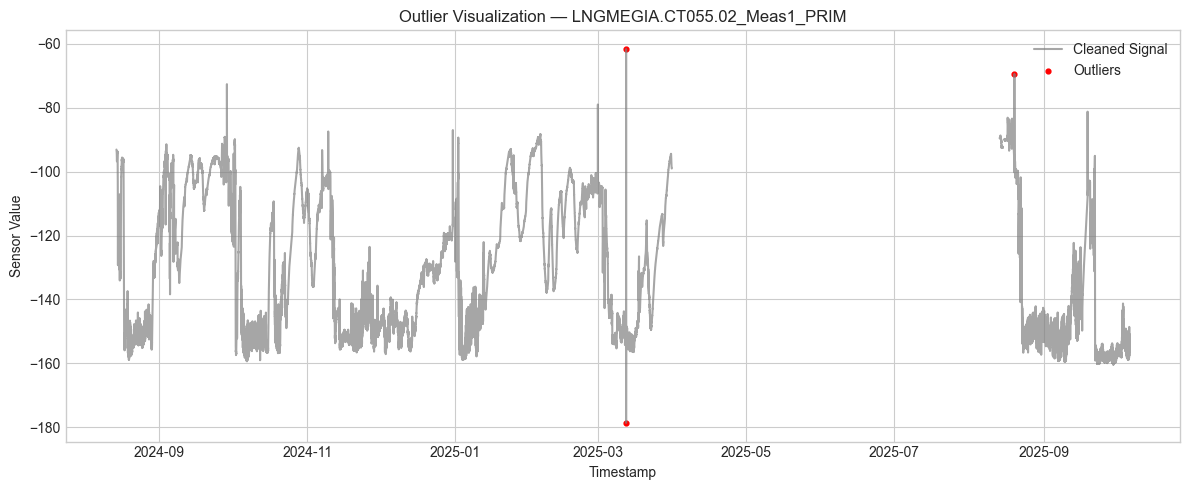

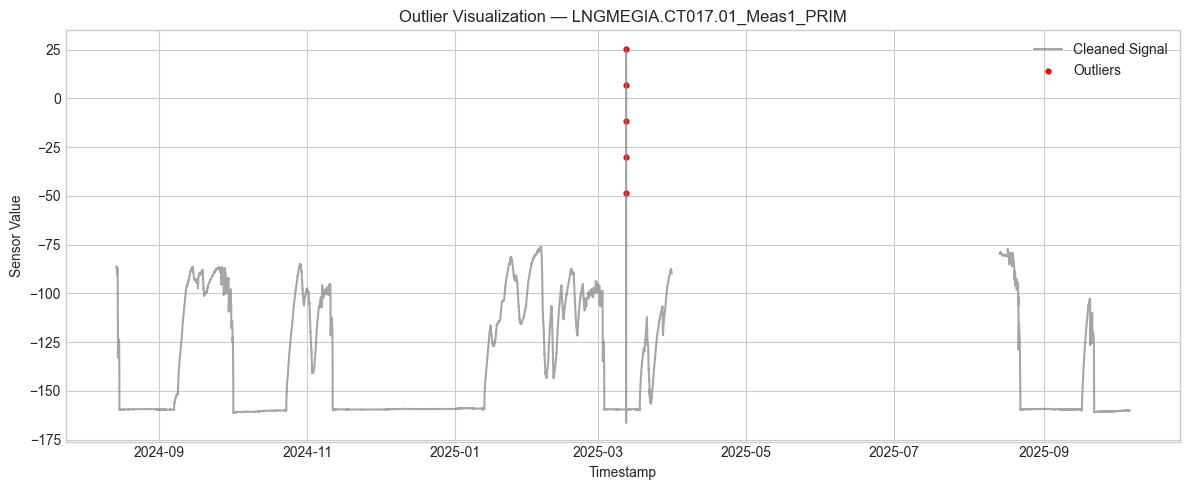

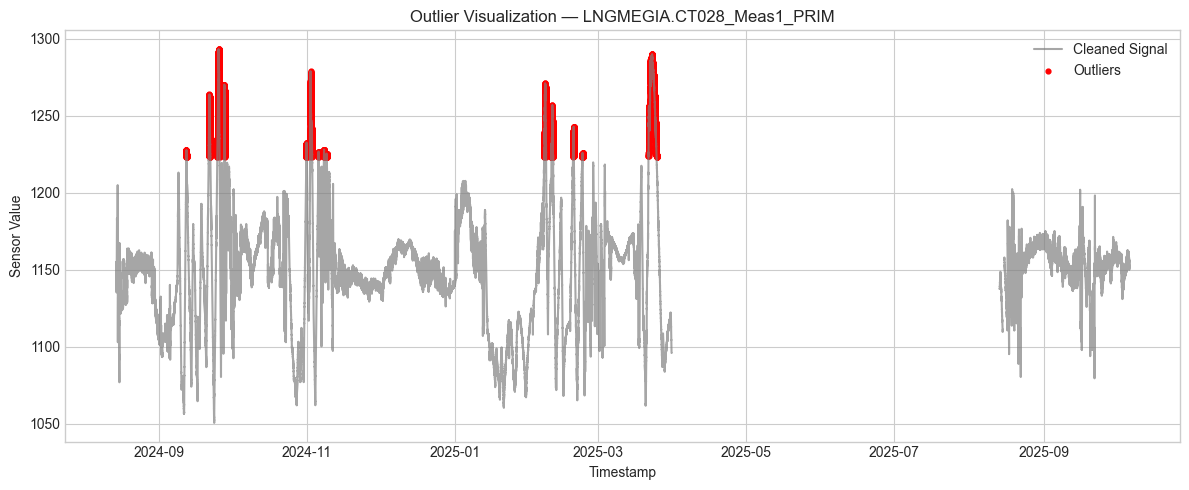

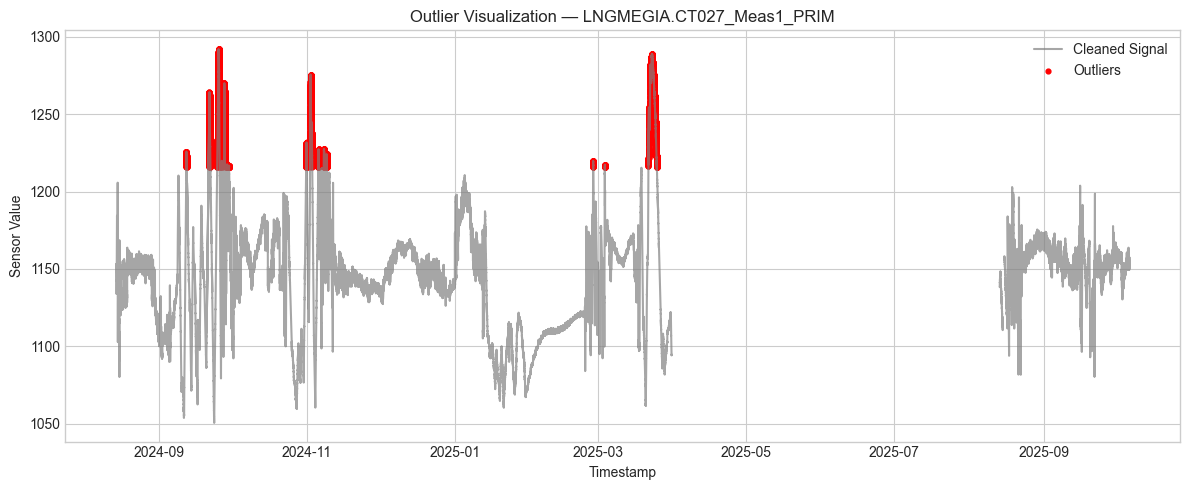

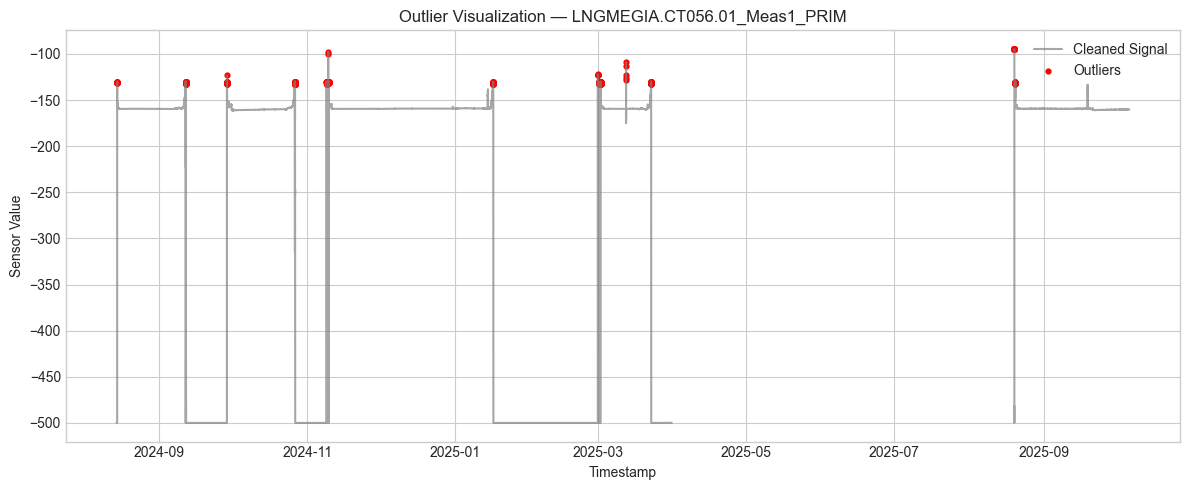

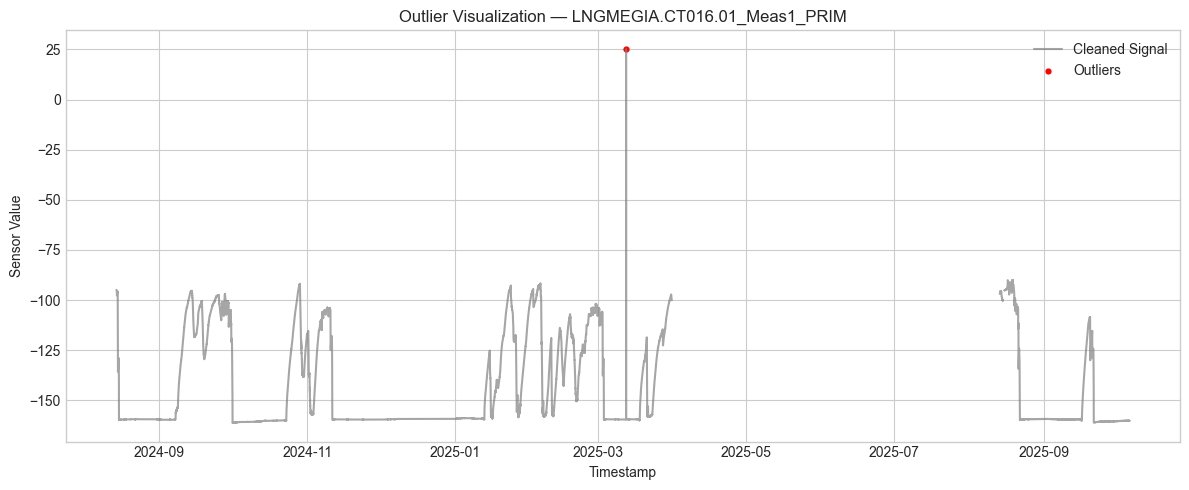

In [ ]:
def plot_outliers(sensor_name):
    clean_path = os.path.join(CLEAN_DIR, f"{sensor_name}_cleaned.csv")
    outlier_path = os.path.join(OUTLIER_DIR, f"{sensor_name}_outliers.csv")

    if not os.path.exists(clean_path) or not os.path.exists(outlier_path):
        print(f"Skipping {sensor_name} (missing cleaned/outlier file)")
        return

    df_clean = pd.read_csv(clean_path, parse_dates=["Timestamp"])
    df_out = pd.read_csv(outlier_path, parse_dates=["Timestamp"])

    plt.figure(figsize=(12, 5))
    plt.plot(df_clean["Timestamp"], df_clean["Value"],
             label="Cleaned Signal", color="gray", alpha=0.7)
    plt.scatter(df_out["Timestamp"], df_out["Value"],
                color="red", s=12, label="Outliers")
    plt.title(f"Outlier Visualization — {sensor_name}")
    plt.xlabel("Timestamp")
    plt.ylabel("Sensor Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Iterate through all outlier files in the directory
outlier_files = [f for f in os.listdir(OUTLIER_DIR) if f.endswith("_outliers.csv")]
if not outlier_files:
    print("No outlier files found.")
else:
    for file in outlier_files:
        sensor_name = file.replace("_outliers.csv", "")
        plot_outliers(sensor_name)

## Next Steps

- Advance to the **Statistical Diagnostics Layer**, where heartbeat and variance analyses validate whether sensors are alive, frozen, or degraded.  
- The diagnostics phase filters out inactive sensors before deeper outlier verification or ML modeling.
